# 0. Load and clean the data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("metadata_vowels_acoustics.csv")

VOWELS = ["a", "i", "u", "e", "o"]

df = pd.read_csv(DATA_PATH)

# Keep only the five Japanese vowels
df_v = df[
    df["label"].isin(VOWELS)
].copy()

print("Rows:", len(df_v))
print("Speakers:", df_v["speaker_id"].nunique())

df_v.head()

Rows: 447265
Speakers: 98


,label,speaker_id,sentence_id,segment_id,duration_s,f0_median_hz,f0_mean_hz,f1_hz,f2_hz,f3_hz
0,e,jvs001,BASIC5000_0025,2,0.09,217.729255,218.190985,490.257251,1946.516170,2529.382639
1,i,jvs001,BASIC5000_0025,4,0.07,298.695927,298.695927,479.977846,2392.671481,3276.838282
2,u,jvs001,BASIC5000_0025,6,0.03,NaN,NaN,401.369689,1829.402224,3037.621599
3,i,jvs001,BASIC5000_0025,8,0.04,NaN,NaN,379.405113,2210.958181,2858.730309
4,o,jvs001,BASIC5000_0025,10,0.14,113.204382,116.263264,715.297445,883.326722,3037.333037


In [2]:
df_f = df_v.dropna(
    subset=["f1_hz", "f2_hz"]
).copy()

print("Usable F1/F2 tokens:", len(df_f))

Usable F1/F2 tokens: 447103


# 1. /a i u e o/ proportions

Overall counts and proportions:

In [3]:
vowel_counts = (
    df_v["label"]
    .value_counts()
    .reindex(VOWELS)
)

vowel_proportions = (
    df_v["label"]
    .value_counts(normalize=True)
    .reindex(VOWELS)
)

vowel_stats = pd.DataFrame({
    "count": vowel_counts,
    "proportion": vowel_proportions,
})

vowel_stats["percentage"] = (
    vowel_stats["proportion"] * 100
)

vowel_stats

,count,proportion,percentage
label,,,
a,109561,0.244958,24.495769
i,76601,0.171265,17.126536
u,81892,0.183095,18.309503
e,63486,0.141943,14.194270
o,115725,0.258739,25.873923


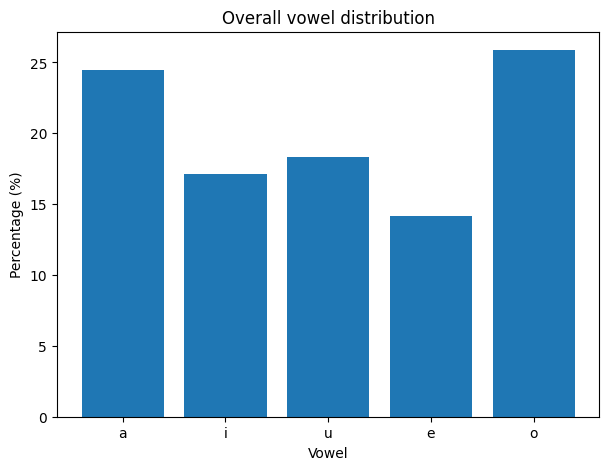

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    vowel_stats.index,
    vowel_stats["percentage"],
)

ax.set_xlabel("Vowel")
ax.set_ylabel("Percentage (%)")
ax.set_title("Overall vowel distribution")

plt.show()

Proportions within each speaker

In [5]:
speaker_vowel_counts = pd.crosstab(
    df_v["speaker_id"],
    df_v["label"],
)

speaker_vowel_counts = speaker_vowel_counts.reindex(
    columns=VOWELS,
    fill_value=0,
)

speaker_vowel_proportions = (
    speaker_vowel_counts
    .div(
        speaker_vowel_counts.sum(axis=1),
        axis=0,
    )
)

speaker_vowel_proportions.head()

speaker_vowel_summary = pd.DataFrame({
    "mean_proportion": speaker_vowel_proportions.mean(),
    "sd_proportion": speaker_vowel_proportions.std(),
    "min_proportion": speaker_vowel_proportions.min(),
    "max_proportion": speaker_vowel_proportions.max(),
})

speaker_vowel_summary

,mean_proportion,sd_proportion,min_proportion,max_proportion
label,,,,
a,0.244962,0.002885,0.238728,0.252155
i,0.171268,0.002063,0.167181,0.176431
u,0.183100,0.002418,0.177611,0.191368
e,0.141944,0.002177,0.136664,0.147137
o,0.258727,0.003185,0.251042,0.264398


# 2. F1–F2 vowel space

In [6]:
def plot_vowel_space(
    data,
    title=None,
    show_tokens=True,
    show_centroids=True,
    alpha=0.15,
    figsize=(7, 6),
):
    fig, ax = plt.subplots(figsize=figsize)

    for vowel in VOWELS:

        d = data[
            data["label"] == vowel
        ]

        if len(d) == 0:
            continue

        if show_tokens:
            ax.scatter(
                d["f2_hz"],
                d["f1_hz"],
                alpha=alpha,
                s=15,
                label=vowel,
            )

        if show_centroids:
            f1_mean = d["f1_hz"].mean()
            f2_mean = d["f2_hz"].mean()

            ax.scatter(
                f2_mean,
                f1_mean,
                s=120,
                marker="x",
                linewidths=3,
            )

            ax.text(
                f2_mean,
                f1_mean,
                vowel,
                fontsize=12,
            )

    ax.set_xlabel("F2 (Hz)")
    ax.set_ylabel("F1 (Hz)")

    # Conventional vowel-space orientation
    ax.invert_xaxis()
    ax.invert_yaxis()

    if title is not None:
        ax.set_title(title)

    if show_tokens:
        ax.legend(title="Vowel")

    plt.show()

Plot one speaker

For example:

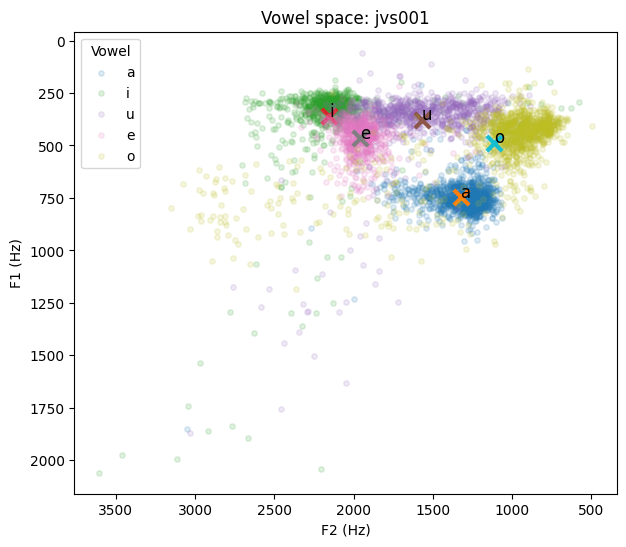

In [7]:
speaker = "jvs001"

plot_vowel_space(
    df_f[
        df_f["speaker_id"] == speaker
    ],
    title=f"Vowel space: {speaker}",
)

Plot each speaker and save them

In [8]:
OUTPUT_DIR = Path("vowel_spaces")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_vowel_space(data, speaker, output_dir):

    fig, ax = plt.subplots(figsize=(7, 6))

    for vowel in VOWELS:

        d = data[
            data["label"] == vowel
        ]

        if len(d) == 0:
            continue

        ax.scatter(
            d["f2_hz"],
            d["f1_hz"],
            alpha=0.15,
            s=15,
            label=vowel,
        )

        f1_mean = d["f1_hz"].mean()
        f2_mean = d["f2_hz"].mean()

        ax.scatter(
            f2_mean,
            f1_mean,
            s=120,
            marker="x",
            linewidths=3,
        )

        ax.text(
            f2_mean,
            f1_mean,
            vowel,
            fontsize=12,
        )

    ax.invert_xaxis()
    ax.invert_yaxis()

    ax.set_xlabel("F2 (Hz)")
    ax.set_ylabel("F1 (Hz)")
    ax.set_title(f"Vowel space: {speaker}")
    ax.legend(title="Vowel")

    fig.tight_layout()

    fig.savefig(
        output_dir / f"{speaker}_vowel_space.png",
        dpi=200,
    )

    plt.close(fig)


for speaker in sorted(
    df_f["speaker_id"].unique()
):

    save_vowel_space(
        df_f[
            df_f["speaker_id"] == speaker
        ],
        speaker,
        OUTPUT_DIR,
    )

## All speakers together

Because you have hundreds of thousands of tokens, plotting every token will make an unreadable cloud.

A much more informative aggregate plot is to calculate the /a i u e o/ centroid separately for every speaker:

In [9]:
speaker_centroids = (
    df_f
    .groupby(
        ["speaker_id", "label"],
        as_index=False,
    )
    [["f1_hz", "f2_hz"]]
    .mean()
)

speaker_centroids.head()

,speaker_id,label,f1_hz,f2_hz
0,jvs001,a,746.535945,1323.781370
1,jvs001,e,464.148194,1959.564792
2,jvs001,i,360.571918,2152.783091
3,jvs001,o,486.139440,1113.990640
4,jvs001,u,377.010835,1569.832309


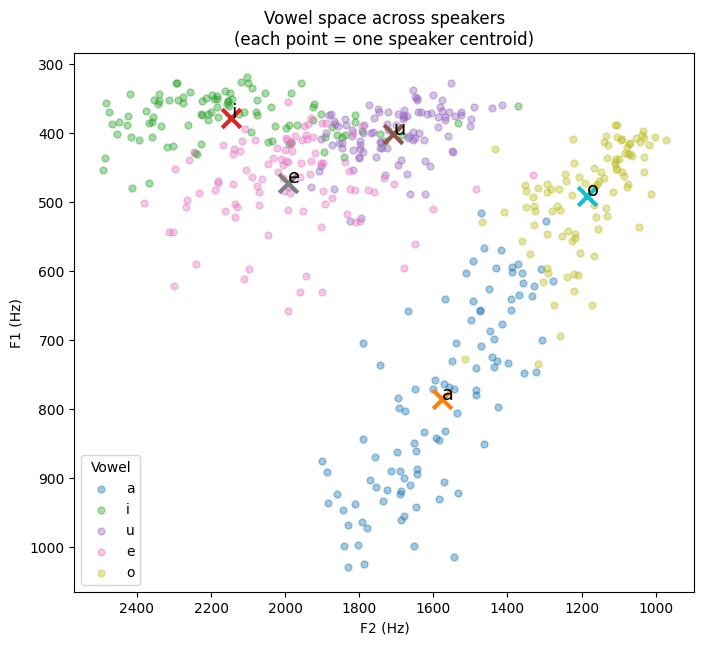

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

for vowel in VOWELS:

    d = speaker_centroids[
        speaker_centroids["label"] == vowel
    ]

    # Each point = one speaker's centroid for this vowel
    ax.scatter(
        d["f2_hz"],
        d["f1_hz"],
        alpha=0.4,
        s=25,
        label=vowel,
    )

    # Grand centroid across speakers
    f1_mean = d["f1_hz"].mean()
    f2_mean = d["f2_hz"].mean()

    ax.scatter(
        f2_mean,
        f1_mean,
        marker="x",
        s=180,
        linewidths=3,
    )

    ax.text(
        f2_mean,
        f1_mean,
        vowel,
        fontsize=14,
    )

ax.invert_xaxis()
ax.invert_yaxis()

ax.set_xlabel("F2 (Hz)")
ax.set_ylabel("F1 (Hz)")
ax.set_title("Vowel space across speakers\n(each point = one speaker centroid)")
ax.legend(title="Vowel")

plt.show()

# Silhouette

In [54]:
df_z = df_f.copy()

for feature in ["f1_hz", "f2_hz"]:
    df_z[feature + "_z"] = df_z[feature]

df_z.head()

df_z_filtered = remove_f1f2_outliers(
    df_z,
    outlier_fraction=0.05,
)

In [55]:
from sklearn.metrics import silhouette_score

VOWELS = ["a", "i", "u", "e", "o"]

speaker_results = []

for speaker, d in df_z_filtered.groupby("speaker_id"):

    d = d[
        d["label"].isin(VOWELS)
    ].dropna(
        subset=["f1_hz_z", "f2_hz_z"]
    ).copy()

    # Need at least 2 vowel categories
    if d["label"].nunique() < 2:
        continue

    X = d[
        ["f1_hz_z", "f2_hz_z"]
    ].to_numpy()

    vowel_labels = d["label"].to_numpy()

    sil = silhouette_score(
        X,
        vowel_labels,
        metric="euclidean",
    )

    speaker_results.append({
        "speaker_id": speaker,
        "silhouette": sil,
        "n_tokens": len(d),
        "n_vowels": d["label"].nunique(),
    })

speaker_silhouette = pd.DataFrame(
    speaker_results
)

speaker_silhouette

,speaker_id,silhouette,n_tokens,n_vowels
0,jvs001,0.362921,4288,5
1,jvs002,0.324922,4324,5
2,jvs003,0.453628,4352,5
3,jvs004,-0.010697,4337,5
4,jvs005,0.348093,4280,5
...,...,...,...,...
93,jvs096,0.145548,4393,5
94,jvs097,0.301918,4329,5
95,jvs098,0.468750,4321,5
96,jvs099,0.290299,4306,5


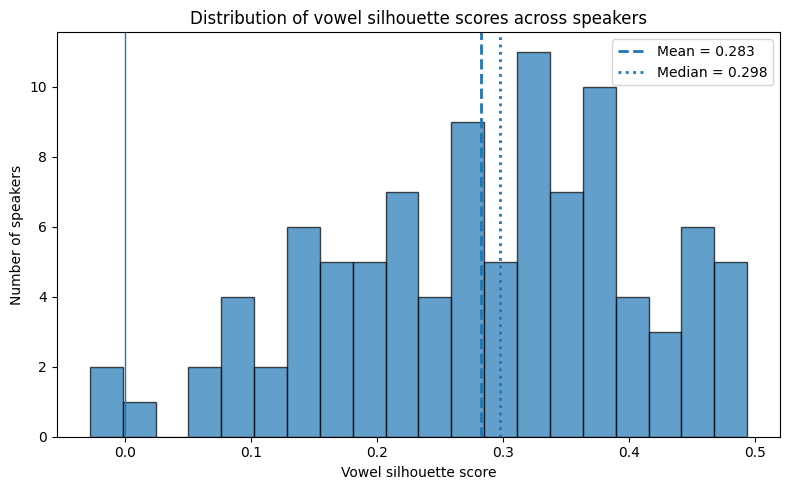

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))

values = speaker_silhouette["silhouette"].dropna()

ax.hist(
    values,
    bins=20,
    edgecolor="black",
    alpha=0.7,
)

# Mean and median
mean_sil = values.mean()
median_sil = values.median()

ax.axvline(
    mean_sil,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_sil:.3f}",
)

ax.axvline(
    median_sil,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_sil:.3f}",
)

# Reference point: silhouette = 0
ax.axvline(
    0,
    linewidth=1,
)

ax.set_xlabel("Vowel silhouette score")
ax.set_ylabel("Number of speakers")
ax.set_title(
    "Distribution of vowel silhouette scores across speakers"
)

ax.legend()

plt.tight_layout()
plt.show()